In [1]:
# Step 1: Check where we are, and whether the CSV is in this folder
import os

print("Current folder:", os.getcwd())
print("Files here:", os.listdir())

import pandas as pd
import numpy as np

Current folder: /Users/zhangliuyang/Desktop/Customer Churn Project
Files here: ['WIL_Project (1) .ipynb', '.DS_Store', 'Dataset_ATS_v2.csv', '.idea']


In [2]:
# Machine learning libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [3]:
# This step loads raw data into the analysis environment
df = pd.read_csv('Dataset_ATS_v2.csv')

In [4]:
# Inspect the first few records to understand dataset structure
df.head()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


In [5]:

# Display dataset schema and identify missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gender           7043 non-null   object
 1   SeniorCitizen    7043 non-null   int64 
 2   Dependents       7043 non-null   object
 3   tenure           7043 non-null   int64 
 4   PhoneService     7043 non-null   object
 5   MultipleLines    7043 non-null   object
 6   InternetService  7043 non-null   object
 7   Contract         7043 non-null   object
 8   MonthlyCharges   7043 non-null   int64 
 9   Churn            7043 non-null   object
dtypes: int64(3), object(7)
memory usage: 550.4+ KB


In [6]:
#check for missing values
df.isnull().sum()

gender             0
SeniorCitizen      0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
Contract           0
MonthlyCharges     0
Churn              0
dtype: int64

In [7]:
#check for NaN values
df.isna().sum()

gender             0
SeniorCitizen      0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
Contract           0
MonthlyCharges     0
Churn              0
dtype: int64

In [8]:
# Display data types of each column
df.dtypes

gender             object
SeniorCitizen       int64
Dependents         object
tenure              int64
PhoneService       object
MultipleLines      object
InternetService    object
Contract           object
MonthlyCharges      int64
Churn              object
dtype: object

In [9]:
# Check for empty strings in the dataset, which may indicate hidden missing data
(df == " ").sum()

gender             0
SeniorCitizen      0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
Contract           0
MonthlyCharges     0
Churn              0
dtype: int64

In [10]:
# Display summary statistics for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.758768
std,0.368612,24.559481,30.091650
min,0.000000,0.000000,18.000000
25%,0.000000,9.000000,36.000000
50%,0.000000,29.000000,70.000000
75%,0.000000,55.000000,90.000000
max,1.000000,72.000000,119.000000


In [11]:
# Convert categorical variables to numerical format using one-hot encoding
# drop_first=True is used to prevent multicollinearity

df_encoded = pd.get_dummies(df, drop_first=True)

In [12]:
# Define features and target variable for modeling

x = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

In [13]:
# Split the dataset into training and testing sets with stratification

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42, stratify = y
)


In [14]:
# Apply feature scaling to normalise numerical values
# Fit scaler only on training data to avoid data leakage

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [15]:
# Display the encoded dataset

df_encoded

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,Contract_One year,Contract_Two year,Churn_Yes
0,0,1,25,False,False,False,False,False,False,False,True
1,0,41,25,True,False,True,False,False,True,False,False
2,0,52,19,False,True,True,False,False,False,False,False
3,0,1,76,False,False,True,False,False,True,False,True
4,0,67,51,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,95,True,False,True,True,False,True,False,True
7039,0,23,91,False,True,True,True,True,True,False,False
7040,0,12,21,True,True,True,False,False,False,False,False
7041,1,12,99,True,False,True,True,True,False,False,True


In [16]:
# Clustering step 1 (continued): Load the dataset into a DataFrame
import pandas as pd

df = pd.read_csv("Dataset_ATS_v2.csv")

print("Rows, Cols =", df.shape)
print(df.head())


Rows, Cols = (7043, 10)
   gender  SeniorCitizen Dependents  tenure PhoneService MultipleLines  \
0  Female              0         No       1           No            No   
1    Male              0         No      41          Yes            No   
2  Female              0        Yes      52          Yes            No   
3  Female              0         No       1          Yes            No   
4    Male              0         No      67          Yes            No   

  InternetService        Contract  MonthlyCharges Churn  
0             DSL  Month-to-month              25   Yes  
1             DSL        One year              25    No  
2             DSL  Month-to-month              19    No  
3             DSL        One year              76   Yes  
4     Fiber optic  Month-to-month              51    No  


In [17]:
# Clustering Step 2: make a feature table for clustering (X)

# 2.1 quick check: columns + missing values
print("Columns:", list(df.columns))
print("\nMissing values per column:\n", df.isna().sum())

# 2.2 (optional) remove spaces in column names (sometimes happens)
df.columns = df.columns.str.strip()

# 2.3 drop the label column (we don't use it for clustering)
# if this line errors, tell me what df.columns prints out
df_features = df.drop(columns=["Churn"])

# 2.4 convert categorical text to numbers (one-hot)
X = pd.get_dummies(df_features, drop_first=True)

print("\nX shape:", X.shape)
print("First 10 X columns:", list(X.columns)[:10])
X.head()


Columns: ['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'MonthlyCharges', 'Churn']

Missing values per column:
 gender             0
SeniorCitizen      0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
Contract           0
MonthlyCharges     0
Churn              0
dtype: int64

X shape: (7043, 10)
First 10 X columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender_Male', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'Contract_One year', 'Contract_Two year']


,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,Contract_One year,Contract_Two year
0,0,1,25,False,False,False,False,False,False,False
1,0,41,25,True,False,True,False,False,True,False
2,0,52,19,False,True,True,False,False,False,False
3,0,1,76,False,False,True,False,False,True,False
4,0,67,51,True,False,True,False,True,False,False


In [18]:
# Step 3: scale the features before clustering

import numpy as np
from sklearn.preprocessing import StandardScaler

# copy X, and turn True/False into 1/0
X_num = X.copy()

for col in X_num.columns:
    if X_num[col].dtype == "bool":
        X_num[col] = X_num[col].astype(int)

print("dtype counts:\n", X_num.dtypes.value_counts())

# standard (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

print("X_scaled shape:", X_scaled.shape)
print("Any NaN?", np.isnan(X_scaled).any())
print("First 3 means (should be ~0):", np.mean(X_scaled, axis=0)[:3])
print("First 3 stds  (should be ~1):", np.std(X_scaled, axis=0)[:3])


dtype counts:
 int64    10
Name: count, dtype: int64
X_scaled shape: (7043, 10)
Any NaN? False
First 3 means (should be ~0): [-4.79210279e-17 -2.44649458e-17 -1.31152287e-16]
First 3 stds  (should be ~1): [1. 1. 1.]


k_list: [2, 3, 4, 5, 6, 7, 8, 9, 10]
inertias: [62068.3129876975, 55368.48384680356, 50406.717104854004, 44925.70464231704, 41432.81762609663, 39417.85282392091, 38235.85163552715, 36747.8968661559, 35837.16811773917]


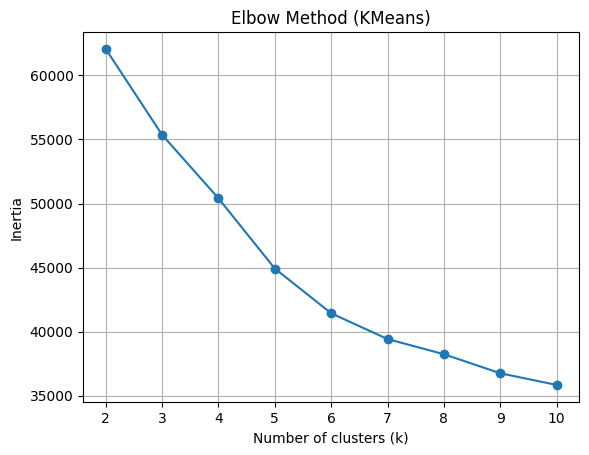

Saved figure to: Clustering_Analysis/Optimal_Number_of_Clusters/elbow_method.png


In [19]:
# Step 4: Elbow method

import os
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# make folder to save results
save_dir = "Clustering_Analysis/Optimal_Number_of_Clusters"
os.makedirs(save_dir, exist_ok=True)

# k values
k_list = list(range(2, 11))  # 2..10
inertias = []

for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

print("k_list:", k_list)
print("inertias:", inertias)

# plot and save
plt.figure()
plt.plot(k_list, inertias, marker="o")
plt.title("Elbow Method (KMeans)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)

out_path = os.path.join(save_dir, "elbow_method.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure to:", out_path)


In [20]:
# Step 5:final KMeans (k=5)

import os
import joblib
from sklearn.cluster import KMeans

# 5.1 choose k (based on elbow)
k_opt = 5

# make sure folders exist (just in case)
model_dir = "Clustering_Analysis/Trained_KMeans_Model"
out_dir = "Clustering_Analysis/Cluster_Visualisation_and_Insights"
os.makedirs(model_dir, exist_ok=True)
os.makedirs(out_dir, exist_ok=True)

# 5.3 train model
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)   # X_scaled is your scaled feature matrix

print("Clusters created:", len(set(clusters)))
print("Cluster labels sample:", clusters[:10])

# use cluster labels back to original data (df)
df_with_cluster = df.copy()
df_with_cluster["Cluster"] = clusters

# quick check: how many in each cluster
print("\nCluster counts:")
print(df_with_cluster["Cluster"].value_counts().sort_index())

# save outputs
csv_path = os.path.join(out_dir, "data_with_clusters.csv")
df_with_cluster.to_csv(csv_path, index=False)
print("\nSaved clustered data to:", csv_path)

model_path = os.path.join(model_dir, f"kmeans_k{k_opt}_model.pkl")
scaler_path = os.path.join(model_dir, "scaler_for_clustering.pkl")

joblib.dump(kmeans, model_path)
joblib.dump(scaler, scaler_path)

print("Saved model to:", model_path)
print("Saved scaler to:", scaler_path)


Clusters created: 5
Cluster labels sample: [3 1 1 1 2 4 2 1 2 1]

Cluster counts:
Cluster
0    1299
1    2003
2    2021
3     682
4    1038
Name: count, dtype: int64

Saved clustered data to: Clustering_Analysis/Cluster_Visualisation_and_Insights/data_with_clusters.csv
Saved model to: Clustering_Analysis/Trained_KMeans_Model/kmeans_k5_model.pkl
Saved scaler to: Clustering_Analysis/Trained_KMeans_Model/scaler_for_clustering.pkl


In [21]:
# Step 6: load the clustered dataset

import pandas as pd

path = "Clustering_Analysis/Cluster_Visualisation_and_Insights/data_with_clusters.csv"

df2 = pd.read_csv(path)

print("Loaded file:", path)
print("Shape (rows, cols):", df2.shape)

print("\nFirst 5 rows:")
display(df2.head())

print("\nColumns list:")
print(list(df2.columns))

# check key columns exist
print("\nHas 'Cluster' column?", "Cluster" in df2.columns)
print("Has 'Churn' column?", "Churn" in df2.columns)

# quick sanity checks
if "Cluster" in df2.columns:
    print("\nCluster counts:")
    print(df2["Cluster"].value_counts().sort_index())

if "Churn" in df2.columns:
    print("\nChurn unique values:")
    print(df2["Churn"].value_counts(dropna=False))


Loaded file: Clustering_Analysis/Cluster_Visualisation_and_Insights/data_with_clusters.csv
Shape (rows, cols): (7043, 11)

First 5 rows:


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn,Cluster
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes,3
1,Male,0,No,41,Yes,No,DSL,One year,25,No,1
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No,1
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes,1
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No,2



Columns list:
['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'MonthlyCharges', 'Churn', 'Cluster']

Has 'Cluster' column? True
Has 'Churn' column? True

Cluster counts:
Cluster
0    1299
1    2003
2    2021
3     682
4    1038
Name: count, dtype: int64

Churn unique values:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [22]:
# churn rate per cluster

df3 = df2.copy()

#convert Churn to numeric flag
df3["Churn_flag"] = df3["Churn"].map({"Yes": 1, "No": 0})

# if there are unexpected values, Churn_flag may become NaN
print("Any NaN in Churn_flag?", df3["Churn_flag"].isna().any())
print(df3["Churn_flag"].value_counts(dropna=False))

# group by cluster and calculate:
# count = total customers in that cluster
# sum   = number of churned customers (because 1s add up)
# mean  = churn rate
summary = df3.groupby("Cluster")["Churn_flag"].agg(["count", "sum", "mean"])

# rename columns
summary = summary.rename(columns={
    "count": "customers",
    "sum": "churn_yes",
    "mean": "churn_rate"
})

# add percentage column
summary["churn_rate_pct"] = summary["churn_rate"] * 100

# sort by churn rate (high -> low) so we can see the risky cluster first
summary_sorted = summary.sort_values("churn_rate", ascending=False)

print("\nChurn rate by cluster (sorted):")
display(summary_sorted)

# overall churn rate (for comparison)
overall_rate = df3["Churn_flag"].mean() * 100
print("\nOverall churn rate (%):", overall_rate)


Any NaN in Churn_flag? False
Churn_flag
0    5174
1    1869
Name: count, dtype: int64

Churn rate by cluster (sorted):


,customers,churn_yes,churn_rate,churn_rate_pct
Cluster,,,,
4,1038,432,0.416185,41.618497
3,682,170,0.249267,24.926686
1,2003,491,0.245132,24.513230
2,2021,475,0.235032,23.503216
0,1299,301,0.231717,23.171671



Overall churn rate (%): 26.536987079369588


In [23]:
#each cluster's churn rate

df4 = df2.copy()

# churn flag (Yes=1, No=0)
df4["Churn_flag"] = df4["Churn"].map({"Yes": 1, "No": 0})

# group by cluster
cluster_profile = df4.groupby("Cluster").agg(
    customers=("Churn_flag", "size"),
    churn_rate=("Churn_flag", "mean"),
    avg_tenure=("tenure", "mean"),
    avg_monthly=("MonthlyCharges", "mean"),
    pct_senior=("SeniorCitizen", "mean")   # 0/1 mean = proportion
)
cluster_profile["churn_rate_pct"] = cluster_profile["churn_rate"] * 100
cluster_profile["pct_senior_pct"] = cluster_profile["pct_senior"] * 100

# sort by churn rate
cluster_profile_sorted = cluster_profile.sort_values("churn_rate", ascending=False)

display(cluster_profile_sorted)


,customers,churn_rate,avg_tenure,avg_monthly,pct_senior,churn_rate_pct,pct_senior_pct
Cluster,,,,,,,
4,1038,0.416185,33.497110,83.695568,1.000000,41.618497,100.000000
3,682,0.249267,31.737537,42.017595,0.152493,24.926686,15.249267
1,2003,0.245132,31.586620,63.789815,0.000000,24.513230,0.000000
2,2021,0.235032,32.880752,63.544780,0.000000,23.503216,0.000000
0,1299,0.231717,32.220939,64.949192,0.000000,23.171671,0.000000


In [24]:
# check category distribution inside each cluster

import pandas as pd

df5 = df2.copy()

# show % table
def show_pct(col_name):
    print("\n==============================")
    print("Column:", col_name)
    print("==============================")

    # count table
    ct = pd.crosstab(df5["Cluster"], df5[col_name])
    print("\nCounts:")
    display(ct)

    # percent table
    pct = pd.crosstab(df5["Cluster"], df5[col_name], normalize="index") * 100
    print("\nPercent (% within cluster):")
    display(pct.round(2))

    return ct, pct

# Contract
ct_contract, pct_contract = show_pct("Contract")

# InternetService
ct_internet, pct_internet = show_pct("InternetService")

# PhoneService
ct_phone, pct_phone = show_pct("PhoneService")

# MultipleLines
ct_multi, pct_multi = show_pct("MultipleLines")



Column: Contract

Counts:


Contract,Month-to-month,One year,Two year
Cluster,,,
0,0,0,1299
1,1328,675,0
2,1624,397,0
3,361,157,164
4,562,244,232



Percent (% within cluster):


Contract,Month-to-month,One year,Two year
Cluster,,,
0,0.00,0.00,100.00
1,66.30,33.70,0.00
2,80.36,19.64,0.00
3,52.93,23.02,24.05
4,54.14,23.51,22.35



Column: InternetService

Counts:


...

PhoneService,No,Yes
Cluster,,
0,0.0,100.0
1,0.0,100.0
2,0.0,100.0
3,100.0,0.0
4,0.0,100.0



Column: MultipleLines

Counts:


MultipleLines,No,Yes
Cluster,,
0,630,669
1,1606,397
2,820,1201
3,422,260
4,594,444



Percent (% within cluster):


MultipleLines,No,Yes
Cluster,,
0,48.50,51.50
1,80.18,19.82
2,40.57,59.43
3,61.88,38.12
4,57.23,42.77


In [25]:
# read the saved dataset
import pandas as pd
import os

# set the file path
file_path = "Clustering_Analysis/Cluster_Visualisation_and_Insights/data_with_clusters.csv"

# check file
print("Trying to load:", file_path)
print("File exists?", os.path.exists(file_path))

# read data
df_clustered = pd.read_csv(file_path)

# basic sanity checks
print("\nShape (rows, cols):", df_clustered.shape)
print("\nFirst 5 rows:")
print(df_clustered.head())

#check cluster column
print("\nColumns:")
print(list(df_clustered.columns))

# Count how many customers in each cluster
print("\nCluster counts:")
print(df_clustered["Cluster"].value_counts().sort_index())

if "Churn" in df_clustered.columns:
    print("\nChurn value counts:")
    print(df_clustered["Churn"].value_counts(dropna=False))
else:
    print("\nWarning: 'Churn' column not found in this file.")


Trying to load: Clustering_Analysis/Cluster_Visualisation_and_Insights/data_with_clusters.csv
File exists? True

Shape (rows, cols): (7043, 11)

First 5 rows:
   gender  SeniorCitizen Dependents  tenure PhoneService MultipleLines  \
0  Female              0         No       1           No            No   
1    Male              0         No      41          Yes            No   
2  Female              0        Yes      52          Yes            No   
3  Female              0         No       1          Yes            No   
4    Male              0         No      67          Yes            No   

  InternetService        Contract  MonthlyCharges Churn  Cluster  
0             DSL  Month-to-month              25   Yes        3  
1             DSL        One year              25    No        1  
2             DSL  Month-to-month              19    No        1  
3             DSL        One year              76   Yes        1  
4     Fiber optic  Month-to-month              51    No      

In [26]:
df2 = df_clustered.copy()

# create a numeric churn flag
df2["Churn_clean"] = df2["Churn"].astype(str).str.strip().str.lower()
df2["Churn_flag"] = df2["Churn_clean"].map({"yes": 1, "no": 0})

print("Any NaN in Churn_flag?", df2["Churn_flag"].isna().any())
print("\nChurn_flag value counts:")
print(df2["Churn_flag"].value_counts(dropna=False))

# churn rate by cluster
# customers   = number of rows in that cluster
# churn_yes   = how many churned
# churn_rate  = churn_yes / customers
grp = df2.groupby("Cluster")["Churn_flag"]

summary = pd.DataFrame({
    "customers": grp.size(),
    "churn_yes": grp.sum(),
})

summary["churn_rate"] = summary["churn_yes"] / summary["customers"]
summary["churn_rate_pct"] = summary["churn_rate"] * 100

# results
summary_sorted = summary.sort_values("churn_rate", ascending=False)
print("\nChurn rate by cluster (sorted):")
display(summary_sorted)

# overall churn rate
overall_rate = df2["Churn_flag"].mean() * 100
print("\nOverall churn rate (%):", overall_rate)

# save the table
out_path = "Clustering_Analysis/Cluster_Visualisation_and_Insights/churn_rate_by_cluster.csv"
summary_sorted.to_csv(out_path, index=True)
print("\nSaved:", out_path)


Any NaN in Churn_flag? False

Churn_flag value counts:
Churn_flag
0    5174
1    1869
Name: count, dtype: int64

Churn rate by cluster (sorted):


,customers,churn_yes,churn_rate,churn_rate_pct
Cluster,,,,
4,1038,432,0.416185,41.618497
3,682,170,0.249267,24.926686
1,2003,491,0.245132,24.513230
2,2021,475,0.235032,23.503216
0,1299,301,0.231717,23.171671



Overall churn rate (%): 26.536987079369588

Saved: Clustering_Analysis/Cluster_Visualisation_and_Insights/churn_rate_by_cluster.csv


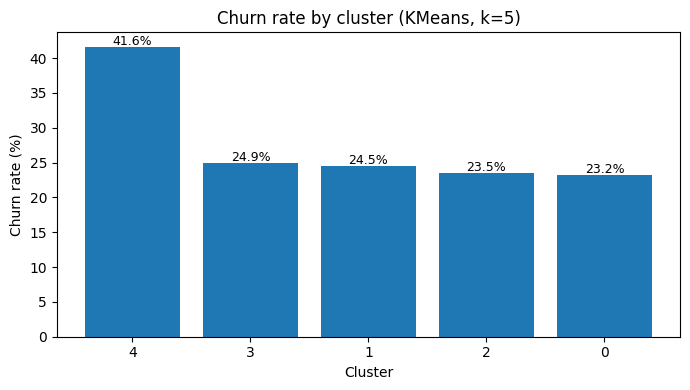

Saved figure to: Clustering_Analysis/Cluster_Visualisation_and_Insights/churn_rate_by_cluster.png


In [27]:
# Visualise churn rate by cluster
import os
import matplotlib.pyplot as plt

out_dir = "Clustering_Analysis/Cluster_Visualisation_and_Insights"
os.makedirs(out_dir, exist_ok=True)

# prepare data for plotting
plot_df = summary_sorted.reset_index()   # brings "Cluster" out from index

# make a simple bar chart
plt.figure(figsize=(7, 4))
plt.bar(plot_df["Cluster"].astype(str), plot_df["churn_rate_pct"])

plt.title("Churn rate by cluster (KMeans, k=5)")
plt.xlabel("Cluster")
plt.ylabel("Churn rate (%)")

for i, v in enumerate(plot_df["churn_rate_pct"]):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()

fig_path = os.path.join(out_dir, "churn_rate_by_cluster.png")
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved figure to:", fig_path)



Loading: Clustering_Analysis/Cluster_Visualisation_and_Insights/data_with_clusters.csv
Columns: ['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'MonthlyCharges', 'Churn', 'Cluster']
Shape: (7043, 11)

Contract counts (by cluster):
Contract  Month-to-month  One year  Two year
Cluster                                     
0                      0         0      1299
1                   1328       675         0
2                   1624       397         0
3                    361       157       164
4                    562       244       232

Contract percent within cluster (%):
Contract  Month-to-month  One year  Two year
Cluster                                     
0                   0.00      0.00    100.00
1                  66.30     33.70      0.00
2                  80.36     19.64      0.00
3                  52.93     23.02     24.05
4                  54.14     23.51     22.35

Saved: Clustering_Analysis/Clust

<Figure size 800x400 with 0 Axes>

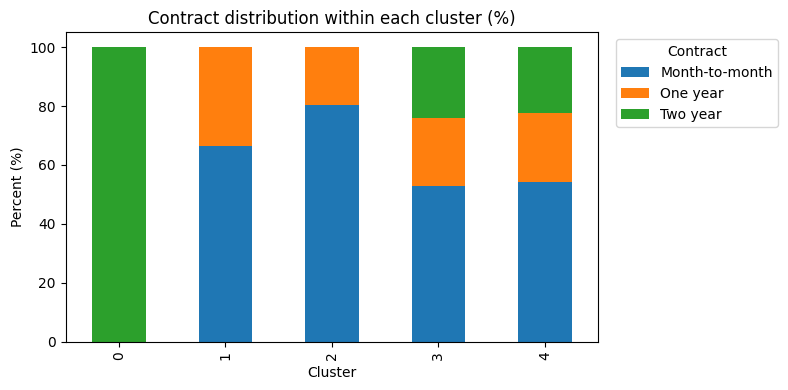

Saved figure to: Clustering_Analysis/Cluster_Visualisation_and_Insights/contract_distribution_by_cluster.png


In [28]:
# contract

import os
import pandas as pd
import matplotlib.pyplot as plt

file_path = "Clustering_Analysis/Cluster_Visualisation_and_Insights/data_with_clusters.csv"
print("Loading:", file_path)

df = pd.read_csv(file_path)

print("Columns:", list(df.columns))
print("Shape:", df.shape)

# counts table
contract_counts = pd.crosstab(df["Cluster"], df["Contract"])
print("\nContract counts (by cluster):")
print(contract_counts)

# percent table: percentage within each cluster
contract_pct = contract_counts.div(contract_counts.sum(axis=1), axis=0) * 100
print("\nContract percent within cluster (%):")
print(contract_pct.round(2))

# save tables
out_dir = "Clustering_Analysis/Cluster_Visualisation_and_Insights"
os.makedirs(out_dir, exist_ok=True)

counts_csv = os.path.join(out_dir, "contract_by_cluster_counts.csv")
pct_csv    = os.path.join(out_dir, "contract_by_cluster_percent.csv")

contract_counts.to_csv(counts_csv)
contract_pct.to_csv(pct_csv)

print("\nSaved:", counts_csv)
print("Saved:", pct_csv)

#plot
plt.figure(figsize=(8, 4))
contract_pct.plot(kind="bar", stacked=True, figsize=(8, 4))

plt.title("Contract distribution within each cluster (%)")
plt.xlabel("Cluster")
plt.ylabel("Percent (%)")
plt.legend(title="Contract", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

fig_path = os.path.join(out_dir, "contract_distribution_by_cluster.png")
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved figure to:", fig_path)


Loading: Clustering_Analysis/Cluster_Visualisation_and_Insights/data_with_clusters.csv
Columns exist? True
Shape: (7043, 11)

InternetService counts (by cluster):
InternetService   DSL  Fiber optic
Cluster                           
0                 965          334
1                2003            0
2                   0         2021
3                 381          301
4                 598          440

InternetService percent within cluster (%):
InternetService     DSL  Fiber optic
Cluster                             
0                 74.29        25.71
1                100.00         0.00
2                  0.00       100.00
3                 55.87        44.13
4                 57.61        42.39

Saved: Clustering_Analysis/Cluster_Visualisation_and_Insights/internetservice_by_cluster_counts.csv
Saved: Clustering_Analysis/Cluster_Visualisation_and_Insights/internetservice_by_cluster_percent.csv


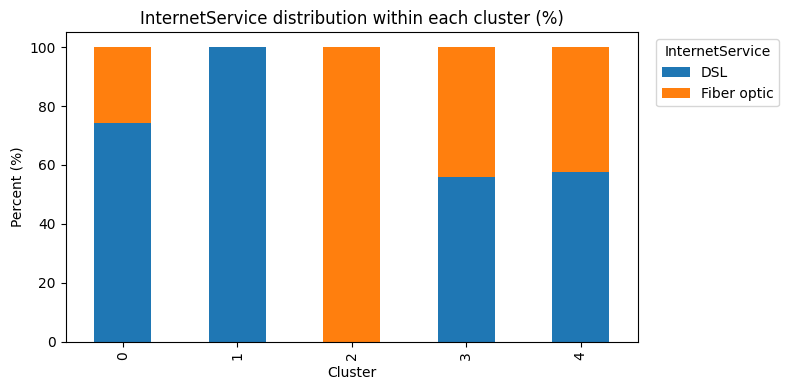

Saved figure to: Clustering_Analysis/Cluster_Visualisation_and_Insights/internetservice_distribution_by_cluster.png


In [29]:
# InternetService

import os
import pandas as pd
import matplotlib.pyplot as plt

# file path
file_path = "Clustering_Analysis/Cluster_Visualisation_and_Insights/data_with_clusters.csv"
print("Loading:", file_path)

df = pd.read_csv(file_path)

need_cols = ["Cluster", "InternetService"]
print("Columns exist?", all(col in df.columns for col in need_cols))
print("Shape:", df.shape)
df["InternetService"] = df["InternetService"].astype(str).str.strip()

# counts table: Cluster x InternetService
internet_counts = pd.crosstab(df["Cluster"], df["InternetService"])
print("\nInternetService counts (by cluster):")
print(internet_counts)

# percent table
internet_pct = internet_counts.div(internet_counts.sum(axis=1), axis=0) * 100
print("\nInternetService percent within cluster (%):")
print(internet_pct.round(2))

# save tables
out_dir = "Clustering_Analysis/Cluster_Visualisation_and_Insights"
os.makedirs(out_dir, exist_ok=True)

counts_csv = os.path.join(out_dir, "internetservice_by_cluster_counts.csv")
pct_csv    = os.path.join(out_dir, "internetservice_by_cluster_percent.csv")

internet_counts.to_csv(counts_csv)
internet_pct.to_csv(pct_csv)

print("\nSaved:", counts_csv)
print("Saved:", pct_csv)

#plot
ax = internet_pct.plot(kind="bar", stacked=True, figsize=(8, 4))

plt.title("InternetService distribution within each cluster (%)")
plt.xlabel("Cluster")
plt.ylabel("Percent (%)")
plt.legend(title="InternetService", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

fig_path = os.path.join(out_dir, "internetservice_distribution_by_cluster.png")
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved figure to:", fig_path)


Shape: (7043, 11)
Has needed columns? True

PhoneService counts (by cluster):
PhoneService   No   Yes
Cluster                
0               0  1299
1               0  2003
2               0  2021
3             682     0
4               0  1038

PhoneService percent within cluster (%):
PhoneService     No    Yes
Cluster                   
0               0.0  100.0
1               0.0  100.0
2               0.0  100.0
3             100.0    0.0
4               0.0  100.0

Saved: Clustering_Analysis/Cluster_Visualisation_and_Insights/phoneservice_by_cluster_counts.csv
Saved: Clustering_Analysis/Cluster_Visualisation_and_Insights/phoneservice_by_cluster_percent.csv


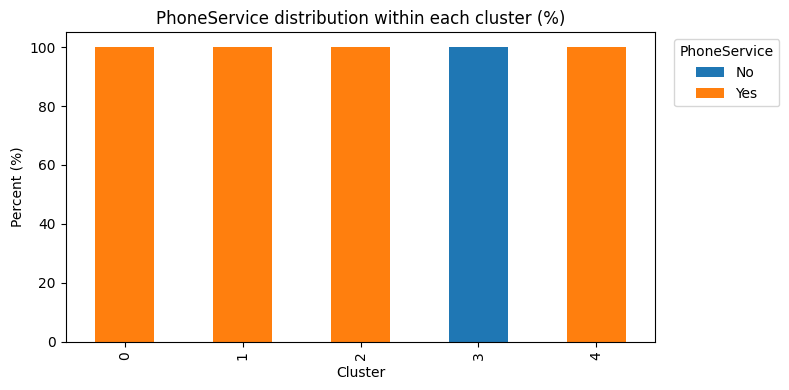

Saved figure to: Clustering_Analysis/Cluster_Visualisation_and_Insights/phoneservice_distribution_by_cluster.png


In [30]:
# PhoneService

import os
import pandas as pd
import matplotlib.pyplot as plt

file_path = "Clustering_Analysis/Cluster_Visualisation_and_Insights/data_with_clusters.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("Has needed columns?", ("Cluster" in df.columns) and ("PhoneService" in df.columns))

df["PhoneService"] = df["PhoneService"].astype(str).str.strip()

# 4) counts table
phone_counts = pd.crosstab(df["Cluster"], df["PhoneService"])
print("\nPhoneService counts (by cluster):")
print(phone_counts)

# 5) percent table
phone_pct = phone_counts.div(phone_counts.sum(axis=1), axis=0) * 100
print("\nPhoneService percent within cluster (%):")
print(phone_pct.round(2))

# 6) save file
out_dir = "Clustering_Analysis/Cluster_Visualisation_and_Insights"
os.makedirs(out_dir, exist_ok=True)

counts_csv = os.path.join(out_dir, "phoneservice_by_cluster_counts.csv")
pct_csv    = os.path.join(out_dir, "phoneservice_by_cluster_percent.csv")

phone_counts.to_csv(counts_csv)
phone_pct.to_csv(pct_csv)

print("\nSaved:", counts_csv)
print("Saved:", pct_csv)

# 7) plot
ax = phone_pct.plot(kind="bar", stacked=True, figsize=(8, 4))

plt.title("PhoneService distribution within each cluster (%)")
plt.xlabel("Cluster")
plt.ylabel("Percent (%)")
plt.legend(title="PhoneService", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

fig_path = os.path.join(out_dir, "phoneservice_distribution_by_cluster.png")
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved figure to:", fig_path)


Shape: (7043, 11)
Has needed columns? True

MultipleLines counts (by cluster):
MultipleLines    No   Yes
Cluster                  
0               630   669
1              1606   397
2               820  1201
3               422   260
4               594   444

MultipleLines percent within cluster (%):
MultipleLines     No    Yes
Cluster                    
0              48.50  51.50
1              80.18  19.82
2              40.57  59.43
3              61.88  38.12
4              57.23  42.77

Saved: Clustering_Analysis/Cluster_Visualisation_and_Insights/multiplelines_by_cluster_counts.csv
Saved: Clustering_Analysis/Cluster_Visualisation_and_Insights/multiplelines_by_cluster_percent.csv


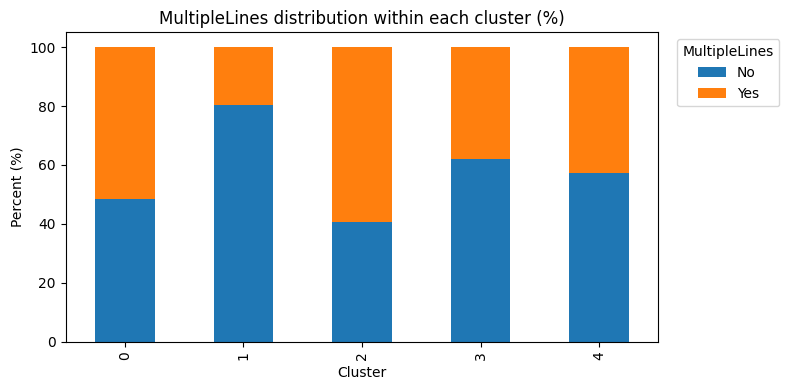

Saved figure to: Clustering_Analysis/Cluster_Visualisation_and_Insights/multiplelines_distribution_by_cluster.png


In [31]:
# MultipleLines

import os
import pandas as pd
import matplotlib.pyplot as plt

file_path = "Clustering_Analysis/Cluster_Visualisation_and_Insights/data_with_clusters.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("Has needed columns?", ("Cluster" in df.columns) and ("MultipleLines" in df.columns))

df["MultipleLines"] = df["MultipleLines"].astype(str).str.strip()

# counts table
ml_counts = pd.crosstab(df["Cluster"], df["MultipleLines"])
print("\nMultipleLines counts (by cluster):")
print(ml_counts)

# percent table
ml_pct = ml_counts.div(ml_counts.sum(axis=1), axis=0) * 100
print("\nMultipleLines percent within cluster (%):")
print(ml_pct.round(2))

# save csv files
out_dir = "Clustering_Analysis/Cluster_Visualisation_and_Insights"
os.makedirs(out_dir, exist_ok=True)

counts_csv = os.path.join(out_dir, "multiplelines_by_cluster_counts.csv")
pct_csv    = os.path.join(out_dir, "multiplelines_by_cluster_percent.csv")

ml_counts.to_csv(counts_csv)
ml_pct.to_csv(pct_csv)

print("\nSaved:", counts_csv)
print("Saved:", pct_csv)

# plot stacked percent
ax = ml_pct.plot(kind="bar", stacked=True, figsize=(8, 4))

plt.title("MultipleLines distribution within each cluster (%)")
plt.xlabel("Cluster")
plt.ylabel("Percent (%)")
plt.legend(title="MultipleLines", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

fig_path = os.path.join(out_dir, "multiplelines_distribution_by_cluster.png")
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved figure to:", fig_path)


In [32]:
# Step 7: build a simple cluster profile summary table

import os
import pandas as pd

# load the saved dataset with clusters
file_path = "Clustering_Analysis/Cluster_Visualisation_and_Insights/data_with_clusters.csv"
df = pd.read_csv(file_path)

print("Loaded:", file_path)
print("Shape:", df.shape)

# make churn_flag
df["Churn_clean"] = df["Churn"].astype(str).str.strip().str.lower()
df["churn_flag"] = df["Churn_clean"].map({"yes": 1, "no": 0})

# basic numeric summary by cluster
base = df.groupby("Cluster").agg(
    customers=("Cluster", "size"),
    churn_rate=("churn_flag", "mean"),
    avg_tenure=("tenure", "mean"),
    avg_monthly=("MonthlyCharges", "mean"),
    pct_senior=("SeniorCitizen", "mean"),
).reset_index()

# convert to percent for some columns
base["churn_rate_pct"] = base["churn_rate"] * 100
base["pct_senior_pct"] = base["pct_senior"] * 100

def top_category_and_pct(data, col_name):

    tmp = (
        data.groupby("Cluster")[col_name]
        .value_counts(normalize=True)
        .rename("pct")
        .reset_index()
        .sort_values(["Cluster", "pct"], ascending=[True, False])
    )
    # keep the top row per cluster
    top = tmp.groupby("Cluster").head(1).copy()
    top.rename(columns={col_name: f"top_{col_name}", "pct": f"top_{col_name}_pct"}, inplace=True)
    top[f"top_{col_name}_pct"] = top[f"top_{col_name}_pct"] * 100
    return top[["Cluster", f"top_{col_name}", f"top_{col_name}_pct"]]

#get top categories for key categorical columns
top_contract = top_category_and_pct(df, "Contract")
top_internet = top_category_and_pct(df, "InternetService")
top_phone    = top_category_and_pct(df, "PhoneService")
top_multi    = top_category_and_pct(df, "MultipleLines")

# merge everything into one table
summary = base.merge(top_contract, on="Cluster", how="left")
summary = summary.merge(top_internet, on="Cluster", how="left")
summary = summary.merge(top_phone, on="Cluster", how="left")
summary = summary.merge(top_multi, on="Cluster", how="left")

# round for nicer display
summary["avg_tenure"] = summary["avg_tenure"].round(2)
summary["avg_monthly"] = summary["avg_monthly"].round(2)
summary["churn_rate_pct"] = summary["churn_rate_pct"].round(2)
summary["pct_senior_pct"] = summary["pct_senior_pct"].round(2)

for c in ["top_Contract_pct", "top_InternetService_pct", "top_PhoneService_pct", "top_MultipleLines_pct"]:
    summary[c] = summary[c].round(2)

print("\nCluster profile summary:")
display(summary)

# save to csv
out_dir = "Clustering_Analysis/Cluster_Visualisation_and_Insights"
os.makedirs(out_dir, exist_ok=True)

out_csv = os.path.join(out_dir, "cluster_profile_summary.csv")
summary.to_csv(out_csv, index=False)
print("\nSaved:", out_csv)


Loaded: Clustering_Analysis/Cluster_Visualisation_and_Insights/data_with_clusters.csv
Shape: (7043, 11)

Cluster profile summary:


,Cluster,customers,churn_rate,avg_tenure,avg_monthly,pct_senior,churn_rate_pct,pct_senior_pct,top_Contract,top_Contract_pct,top_InternetService,top_InternetService_pct,top_PhoneService,top_PhoneService_pct,top_MultipleLines,top_MultipleLines_pct
0,0,1299,0.231717,32.22,64.95,0.000000,23.17,0.00,Two year,100.00,DSL,74.29,Yes,100.0,Yes,51.50
1,1,2003,0.245132,31.59,63.79,0.000000,24.51,0.00,Month-to-month,66.30,DSL,100.00,Yes,100.0,No,80.18
2,2,2021,0.235032,32.88,63.54,0.000000,23.50,0.00,Month-to-month,80.36,Fiber optic,100.00,Yes,100.0,Yes,59.43
3,3,682,0.249267,31.74,42.02,0.152493,24.93,15.25,Month-to-month,52.93,DSL,55.87,No,100.0,No,61.88
4,4,1038,0.416185,33.50,83.70,1.000000,41.62,100.00,Month-to-month,54.14,DSL,57.61,Yes,100.0,No,57.23



Saved: Clustering_Analysis/Cluster_Visualisation_and_Insights/cluster_profile_summary.csv
